In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

## 1. data loading

In [2]:
df=pd.read_csv('books_merged_clean.csv')

In [3]:
df.head()

,title,author,year,language,api_genre,wiki_genre,pages,edition_count,ratings_average,ratings_count,sales_millions,decade
0,Alice's Adventures in Wonderland,Lewis Carroll,1865,English,fantasy,fantasy,133.0,3547,4.043859,228.0,100.0,1860
1,The Wind in the Willows,Kenneth Grahame,1908,English,fantasy,children's literature,192.0,1346,4.035714,56.0,25.0,1900
2,Anne of Green Gables,Lucy Maud Montgomery,1908,English,fantasy,children's novel,309.0,1299,4.284314,102.0,50.0,1900
3,The Hobbit,J. R. R. Tolkien,1937,English,fantasy,fantasy,310.0,482,4.290000,500.0,100.0,1930
4,Harry Potter and the Philosopher's Stone,J. K. Rowling,1997,English,fantasy,fantasy,302.0,400,4.221053,1045.0,120.0,1990


In [4]:
df.shape

(55, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            55 non-null     object 
 1   author           55 non-null     object 
 2   year             55 non-null     int64  
 3   language         55 non-null     object 
 4   api_genre        55 non-null     object 
 5   wiki_genre       55 non-null     object 
 6   pages            55 non-null     float64
 7   edition_count    55 non-null     int64  
 8   ratings_average  55 non-null     float64
 9   ratings_count    55 non-null     float64
 10  sales_millions   55 non-null     float64
 11  decade           55 non-null     int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 5.3+ KB


In [6]:
df.describe()

,year,pages,edition_count,ratings_average,ratings_count,sales_millions,decade
count,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000
mean,1956.927273,352.927273,443.800000,4.080372,191.345455,35.527273,1951.454545
std,51.597751,199.736480,818.450985,0.215689,183.498231,34.542269,51.940785
min,1788.000000,26.000000,58.000000,3.400000,5.000000,10.000000,1780.000000
25%,1938.500000,199.500000,106.500000,3.930311,73.000000,15.000000,1930.000000
50%,1969.000000,339.000000,142.000000,4.096154,117.000000,21.000000,1960.000000
75%,1996.500000,456.500000,285.000000,4.243447,265.500000,46.500000,1990.000000
max,2014.000000,1040.000000,4042.000000,4.511236,1045.000000,200.000000,2010.000000


## 2. descriptive statistics

In [7]:
numeric_cols = ['year', 'pages', 'edition_count', 'ratings_average', 'ratings_count', 'sales_millions']

In [8]:
df[numeric_cols].describe()

,year,pages,edition_count,ratings_average,ratings_count,sales_millions
count,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000
mean,1956.927273,352.927273,443.800000,4.080372,191.345455,35.527273
std,51.597751,199.736480,818.450985,0.215689,183.498231,34.542269
min,1788.000000,26.000000,58.000000,3.400000,5.000000,10.000000
25%,1938.500000,199.500000,106.500000,3.930311,73.000000,15.000000
50%,1969.000000,339.000000,142.000000,4.096154,117.000000,21.000000
75%,1996.500000,456.500000,285.000000,4.243447,265.500000,46.500000
max,2014.000000,1040.000000,4042.000000,4.511236,1045.000000,200.000000


In [9]:
df[numeric_cols].median()

year               1969.000000
pages               339.000000
edition_count       142.000000
ratings_average       4.096154
ratings_count       117.000000
sales_millions       21.000000
dtype: float64

## 3. correlations (pearson & spearman)

In [10]:
corr_pearson = df[numeric_cols].corr(method='pearson')

In [11]:
corr_pearson

,year,pages,edition_count,ratings_average,ratings_count,sales_millions
year,1.000000,0.168749,-0.640983,0.219999,0.125078,-0.298490
pages,0.168749,1.000000,-0.110410,0.018668,-0.120977,-0.080315
edition_count,-0.640983,-0.110410,1.000000,-0.042924,0.165332,0.324471
ratings_average,0.219999,0.018668,-0.042924,1.000000,0.090379,-0.046345
ratings_count,0.125078,-0.120977,0.165332,0.090379,1.000000,0.321538
sales_millions,-0.298490,-0.080315,0.324471,-0.046345,0.321538,1.000000


In [12]:
corr_spearman = df[numeric_cols].corr(method='spearman')

In [13]:
corr_spearman

,year,pages,edition_count,ratings_average,ratings_count,sales_millions
year,1.000000,0.326717,-0.621256,0.078985,0.134957,-0.337022
pages,0.326717,1.000000,-0.215294,0.111456,-0.153662,-0.075971
edition_count,-0.621256,-0.215294,1.000000,-0.141868,0.445489,0.451737
ratings_average,0.078985,0.111456,-0.141868,1.000000,-0.049245,0.027835
ratings_count,0.134957,-0.153662,0.445489,-0.049245,1.000000,0.085391
sales_millions,-0.337022,-0.075971,0.451737,0.027835,0.085391,1.000000


In [14]:
diff = (corr_pearson - corr_spearman).abs()
diff

,year,pages,edition_count,ratings_average,ratings_count,sales_millions
year,0.000000,0.157967,0.019727,0.141014,0.009879,0.038532
pages,0.157967,0.000000,0.104884,0.092787,0.032684,0.004344
edition_count,0.019727,0.104884,0.000000,0.098944,0.280157,0.127266
ratings_average,0.141014,0.092787,0.098944,0.000000,0.139624,0.074180
ratings_count,0.009879,0.032684,0.280157,0.139624,0.000000,0.236147
sales_millions,0.038532,0.004344,0.127266,0.074180,0.236147,0.000000


In [15]:
diff_unstacked = diff.unstack().sort_values(ascending=False)
diff_unstacked.head(10)

ratings_count    edition_count      0.280157
edition_count    ratings_count      0.280157
ratings_count    sales_millions     0.236147
sales_millions   ratings_count      0.236147
pages            year               0.157967
year             pages              0.157967
ratings_average  year               0.141014
year             ratings_average    0.141014
ratings_count    ratings_average    0.139624
ratings_average  ratings_count      0.139624
dtype: float64

In [16]:
pairs = [
    ('year', 'edition_count'),
    ('edition_count', 'sales_millions'),
    ('ratings_count', 'sales_millions'),
    ('year', 'sales_millions'),
    ('pages', 'sales_millions'),
]

In [17]:
for col1, col2 in pairs:
    r_p, p_p = pearsonr(df[col1], df[col2])
    r_s, p_s = spearmanr(df[col1], df[col2])
    print(f'{col1} vs {col2}')
    print(f'  pearson:  r = {r_p:.3f}, p = {p_p:.4f}')
    print(f'  spearman: r = {r_s:.3f}, p = {p_s:.4f}')
    print()

year vs edition_count
  pearson:  r = -0.641, p = 0.0000
  spearman: r = -0.621, p = 0.0000

edition_count vs sales_millions
  pearson:  r = 0.324, p = 0.0157
  spearman: r = 0.452, p = 0.0005

ratings_count vs sales_millions
  pearson:  r = 0.322, p = 0.0167
  spearman: r = 0.085, p = 0.5353

year vs sales_millions
  pearson:  r = -0.298, p = 0.0269
  spearman: r = -0.337, p = 0.0119

pages vs sales_millions
  pearson:  r = -0.080, p = 0.5600
  spearman: r = -0.076, p = 0.5814



## 4. visualizations

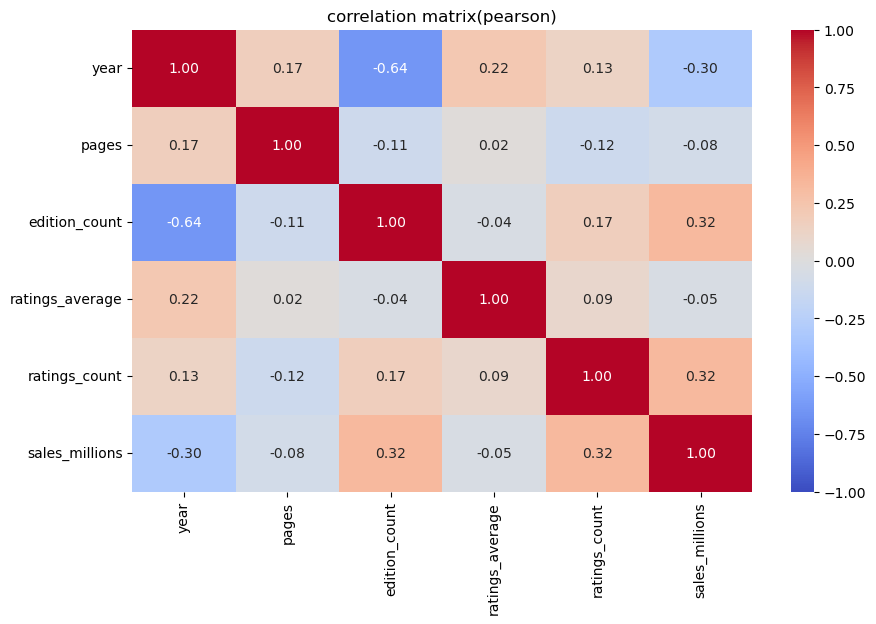

In [18]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('correlation matrix(pearson)')
plt.show()

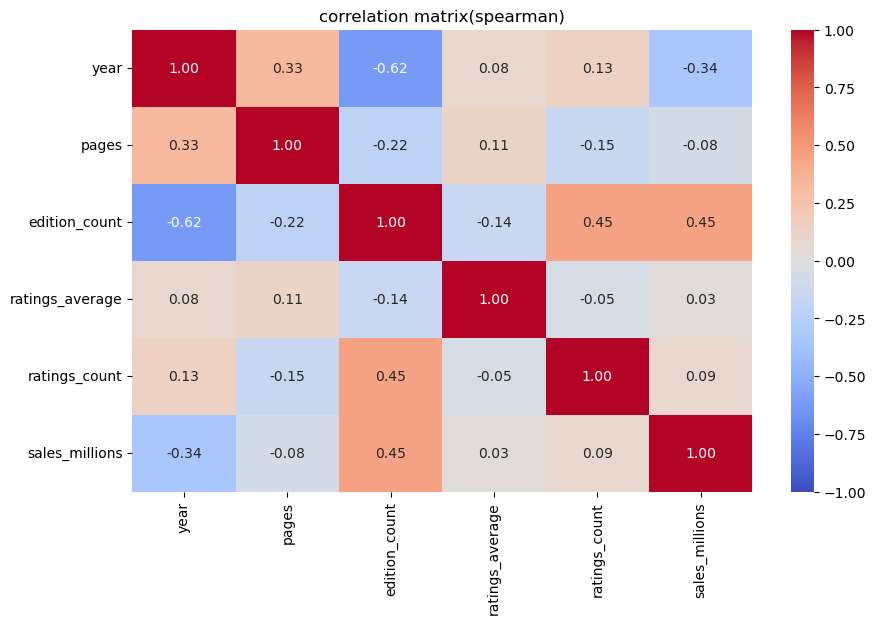

In [19]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('correlation matrix(spearman)')
plt.show()

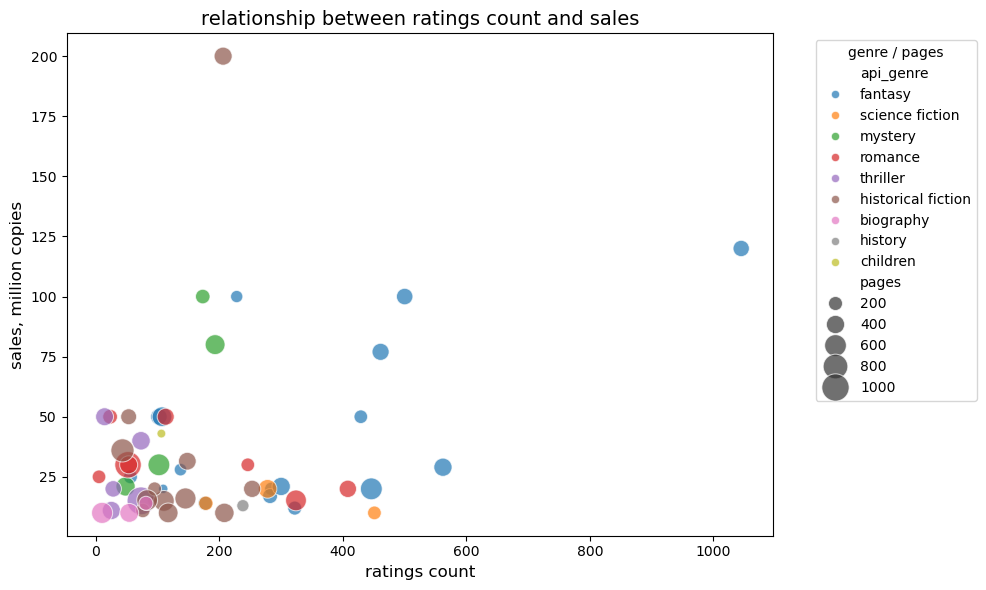

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='ratings_count',
    y='sales_millions',
    hue='api_genre',
    size='pages',
    sizes=(40, 400),
    alpha=0.7
)
plt.title('relationship between ratings count and sales', fontsize=14)
plt.xlabel('ratings count', fontsize=12)
plt.ylabel('sales, million copies', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='genre / pages')
plt.tight_layout()
plt.show()

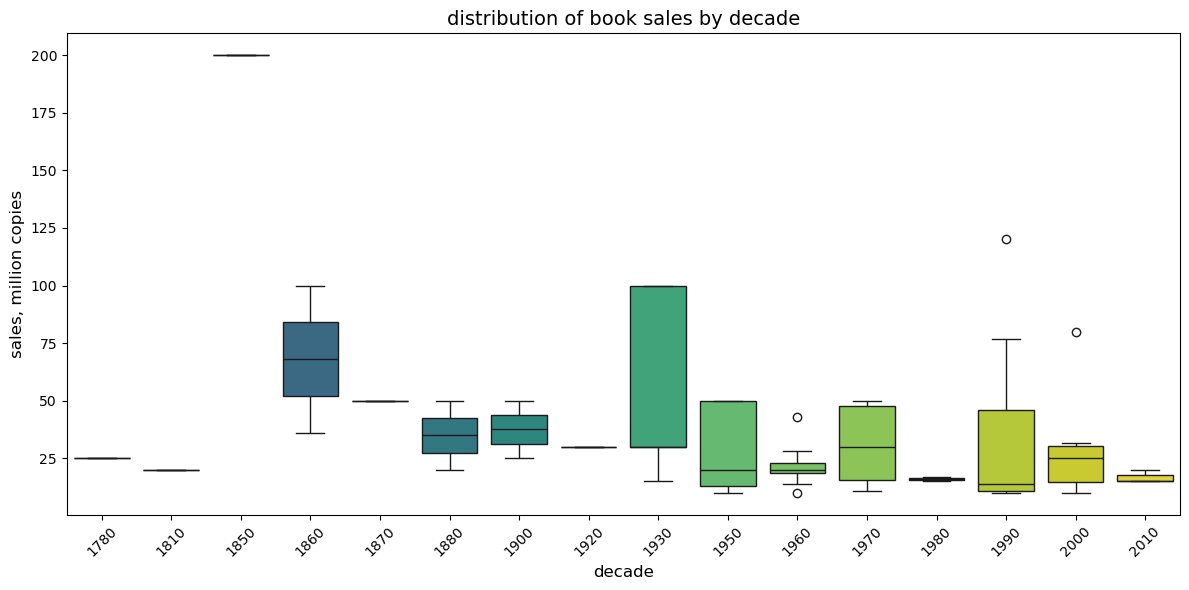

In [21]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x='decade',
    y='sales_millions',
    hue='decade',
    palette='viridis',
    legend=False
)
plt.title('distribution of book sales by decade', fontsize=14)
plt.xlabel('decade', fontsize=12)
plt.ylabel('sales, million copies', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
df['decade'].value_counts().sort_index()

decade
1780    1
1810    1
1850    1
1860    2
1870    1
1880    2
1900    2
1920    1
1930    5
1950    5
1960    8
1970    6
1980    2
1990    7
2000    8
2010    3
Name: count, dtype: int64

In [23]:
df['period'] = pd.cut(
    df['year'],
    bins=[1787, 1899, 1949, 1999, 2014],
    labels=['pre-1900', '1900-1949', '1950-1999', '2000+']
)

In [24]:
df['period'].value_counts()

period
1950-1999    28
2000+        11
pre-1900      8
1900-1949     8
Name: count, dtype: int64

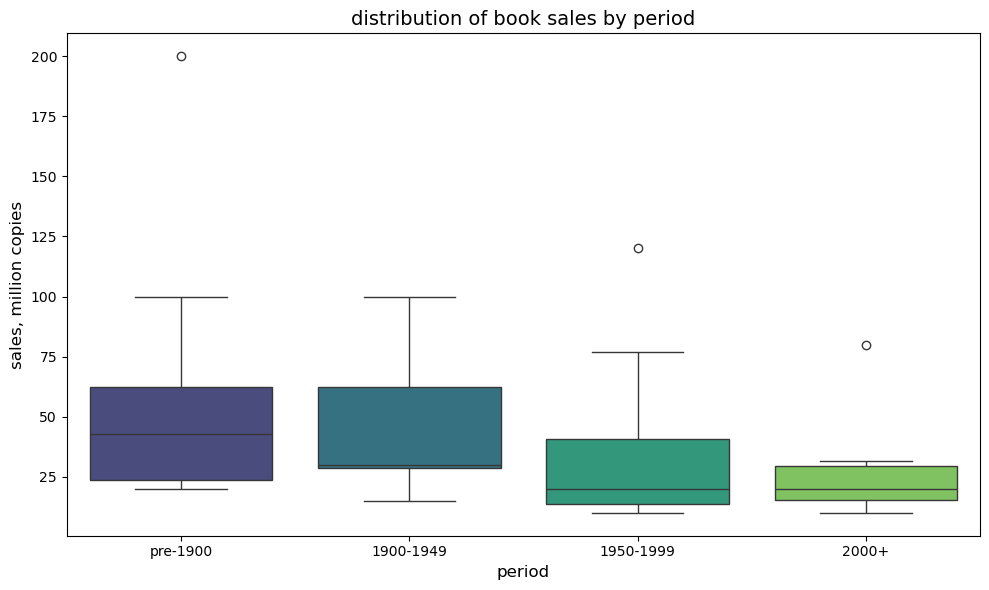

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='period',
    y='sales_millions',
    hue='period',
    palette='viridis',
    legend=False
)
plt.title('distribution of book sales by period', fontsize=14)
plt.xlabel('period', fontsize=12)
plt.ylabel('sales, million copies', fontsize=12)
plt.tight_layout()
plt.show()